## Bar

1. Подключение к db.  

In [5]:
import pandas as pd
import sqlite3


conn = sqlite3.connect("../data/checking-logs.sqlite")

2. SQL-запрос и формирование датафрейма.

In [6]:
query_commits = """
SELECT timestamp
FROM checker
WHERE uid LIKE "user_%"
AND labname IS NOT NULL
"""

df = pd.read_sql(query_commits, conn)
df["timestamp"] = pd.to_datetime(df["timestamp"])

df["hour"] = df["timestamp"].dt.hour
df["timestamp"] = df["timestamp"].dt.date

df.rename(columns={"timestamp":"date"}, inplace=True)

time_bins = [0, 4, 10, 17, 24]
time_labels = ["night", "morning", "afternoon", "evening"]

df["daytime"] = pd.cut(df["hour"], bins=time_bins, labels=time_labels, right=False)

df = df.groupby(["date", "daytime"], observed=False).size().unstack(fill_value=0)

df.tail(10)

daytime,night,morning,afternoon,evening
date,,,,
2020-05-12,0,40,67,215
2020-05-13,0,4,59,148
2020-05-14,4,3,291,277
2020-05-15,0,0,10,0
2020-05-16,0,0,0,4
2020-05-17,0,2,10,36
2020-05-18,0,0,1,2
2020-05-19,0,12,18,4
2020-05-20,0,7,11,10


3. Построение графика 

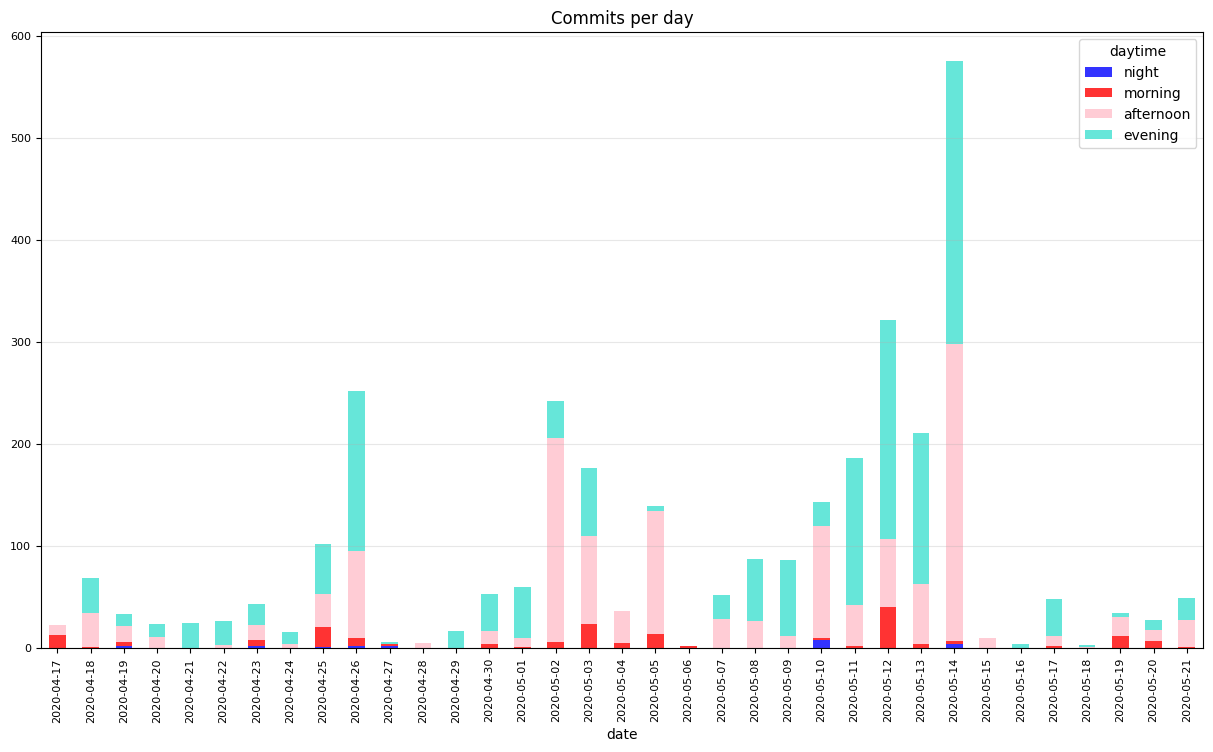

In [7]:
ax = df.plot.bar(
    figsize=(15, 8), 
    stacked=True, 
    color={"night": "blue", "morning": "red", "afternoon": "pink", "evening": "turquoise"}, 
    alpha=0.8, 
    fontsize=8,
    xlabel="date",
    title="Commits per day"
    )

ax.grid(axis='y', alpha=0.3)

In [8]:
conn.close()

Вопросы:

В какое время наши пользователи обычно выполняют лабораторные работы: ночью, утром, днём или вечером? 
Ответ: afternoon, evening

Какой день имеет наибольшее количество коммитов и количество коммитов выше вечером, чем днем?
Ответ: 2020-05-12